<h1 align="center"><strong>ACTIVIDAD 1 ML: Desarrollo de un Modelo de Aprendizaje Supervisado</strong></h1>



Para realizar esta actividad, vamos a crear un proyecto de **aprendizaje supervisado**. El objetivo es aplicar un modelo de Machine Learning a un conjunto de datos deportivos reales. En este caso, hemos elegido un dataset con datos de futbolistas chinos. El objetivo es predecir la probabilidad de que un futbolista sufra una lesión relevante (≥7 días de ausencia) en la siguiente temporada de competición.

## Índice

- [1. Dataset](#1-dataset)
- [2. EDA (Exploratory Data Analysis)](#2-eda-exploratory-data-analysis)
- [3. Preprocesamiento: Limpieza de Datos, Nulos y Feature Engineering](#3-preprocesamiento-limpieza-de-datos-nulos-y-feature-engineering)
- [4. Definición del Target: Selección y Justificación](#4-definición-del-target-selección-y-justificación)
- [5. Algoritmo: Elección y Justificación](#5-algoritmo-elección-y-justificación)
- [6. Entrenamiento](#6-entrenamiento)
- [7. Crear un Nuevo Jugador Ficticio](#7-crear-un-nuevo-jugador-ficticio)
  
<br>


---


 
## **1. Dataset**

El dataset empleado está compuesto por **800 futbolistas universitarios**. Cada fila corresponde a un jugador e incluye variables relacionadas con:

|      Categoría      |            Variables            |
|:-------------------:|:--------------------------------:|
| **Antropometría** | `Age`<br>`Height_cm`<br>`Weight_kg`<br>`BMI` |
| **Contexto Deportivo** | `Position`<br>`Training_Hours_Per_Week`<br>`Matches_Played_Past_Season` |
| **Historial de Lesiones** | `Previous_Injury_Count` |
| **Fitness / Rendimiento** | `Knee_Strength_Score`<br>`Hamstring_Flexibility`<br>`Reaction_Time_ms`<br>`Balance_Test_Score`<br>`Sprint_Speed_10m_s`<br>`Agility_Score` |
| **Estilo de Vida** | `Sleep_Hours_Per_Night`<br>`Stress_Level_Score`<br>`Nutrition_Quality_Score` |
| **Hábito de Calentar** | `Warmup_Routine_Adherence` |


La variable target a predecir es:

==> **`Injury_Next_Season`**. **(0 = no lesión, 1 = lesión ≥7 días)**.

Indica si el jugador sufrió una lesión que no le permite jugar siete o más días en la siguiente temporada.

---


### **1.1. Importación de Librerias y Carga del Dataset**

In [3]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del archivo CSV
csv_futbol = "/Users/mariogodoy/PYTHONIA/Master-IA-Universidad-Europea-25-26/dataset/data.csv"
df = pd.read_csv(csv_futbol)

---

### **1.2. Análisis Inicial del Dataset**
Antes de empezar a trabajar con el modelo es necesario revisar los datos para saber qué información tenemos y en qué estado se encuentra el dataset.

Para ello utilizaremos:

* `head`: muestra las primeras filas del dataset para comprobar que los datos se han cargado correctamente. Con `sample` vemos 5 filas aleatorias del dataset.

* `shape`: permite conocer cuántas filas y columnas tiene el dataset.

* `info()`: muestra el tipo de cada variable para identificar si hay datos en formato texto o numérico.

In [4]:
# Muestra de datos. Usamos `sample` para ver filas aleatorias.
print("\n--- MUESTRA DE POSICION ---")
display(df[['Position']].sample(5))



--- MUESTRA DE POSICION ---


,Position
287,Goalkeeper
555,Midfielder
250,Defender
46,Defender
294,Defender


In [5]:
# Tamaño del Dataset
print("--- DIMENSIONES ---")
print(f"Tenemos {df.shape[0]} filas (jugadores) y {df.shape[1]} columnas (estadísticas).")

# Tipos de Variables
print("\n--- TIPOS DE VARIABLES ---")
df.info()

--- DIMENSIONES ---
Tenemos 800 filas (jugadores) y 19 columnas (estadísticas).

--- TIPOS DE VARIABLES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previous_Injury_Count       800 non-null    int64  
 7   Knee_Strength_Score         800 non-null    float64
 8   Hamstring_Flexibility       800 non-null    float64
 9   Reaction_Time_ms            800 non-null    float64
 10  Balance_Test_Score          800 non-null    float64
 11  Sprint_Speed_10m_s          800 non-null 

---

## **2. EDA (Exploratory Data Analysis)**

### **2.1 Variables Categóricas**
Vemos como se distribuyen las variables categóricas. (En este caso solo tenemos `Position`)

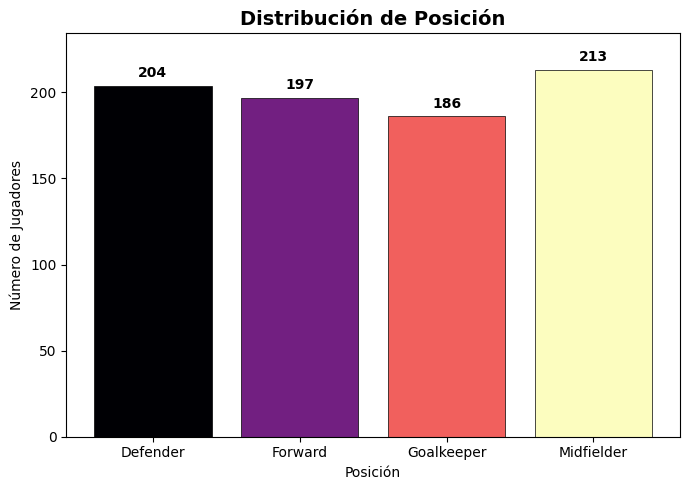

In [6]:
# Aplicamos la librería matplotlib usando lenguaje orientado a objetos
# 1. Preparación de datos 
countpos = df["Position"].value_counts().sort_index()

# 2. Configuración
fig, ax = plt.subplots(figsize=(7, 5))

# 3. Dibujado
colores1 = plt.get_cmap("magma")(np.linspace(0, 1, len(countpos)))
ax.bar(x=countpos.index, height=countpos.values, color=colores1, edgecolor='black', linewidth=0.5)

# 4. Personalización
ax.set_title("Distribución de Posición", fontsize=14, fontweight='bold')
ax.set_xlabel("Posición")
ax.set_ylabel("Número de Jugadores")

# 5. Límites y etiquetas
ax.set_ylim(0, max(countpos.values) * 1.1)

for i, v in enumerate(countpos.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---

### **2.2. Variables Numéricas**
En primer lugar, vemos las estadísticas básicas de las diferentes variables numéricas.

* `describe`: ofrece un resumen estadístico de las variables numéricas.

In [7]:
# Estadísticas básicas
print("\n--- ESTADÍSTICAS BÁSICAS ---")
display(df.describe().T.round(3))


--- ESTADÍSTICAS BÁSICAS ---


,count,mean,std,min,25%,50%,75%,max
Age,800.0,21.135,1.991,18.000,19.000,21.000,23.000,24.000
Height_cm,800.0,177.408,7.149,154.000,173.000,177.000,182.000,200.000
Weight_kg,800.0,73.235,9.929,45.000,66.000,73.000,80.000,105.000
Training_Hours_Per_Week,800.0,9.951,2.610,5.000,8.127,9.896,11.535,18.867
Matches_Played_Past_Season,800.0,22.332,10.312,5.000,13.000,22.000,32.000,39.000
Previous_Injury_Count,800.0,1.536,1.293,0.000,1.000,1.000,2.000,8.000
Knee_Strength_Score,800.0,74.933,6.673,52.391,70.433,74.998,79.632,93.900
Hamstring_Flexibility,800.0,79.154,6.782,58.180,74.496,79.188,83.813,100.000
Reaction_Time_ms,800.0,249.423,22.532,180.000,234.090,249.127,265.105,306.731
Balance_Test_Score,800.0,83.832,6.932,60.059,79.045,84.156,88.878,100.000


---
#### **2.2.1 Distribución del Target y Variables Numéricas Binarias**
Analizamos como se distribuye la varible objetivo `Injury_Next_Season`. Se trata de una variable numerica binaria, es decir, será tratada como una variable categórica.

* `value_counts()`: nos muestra cómo se distribuyen los valores de una variable concreta.



--- DISTRIBUCIÓN DE Injury_Next_Season ---


Injury_Next_Season
0    400
1    400
Name: count, dtype: int64

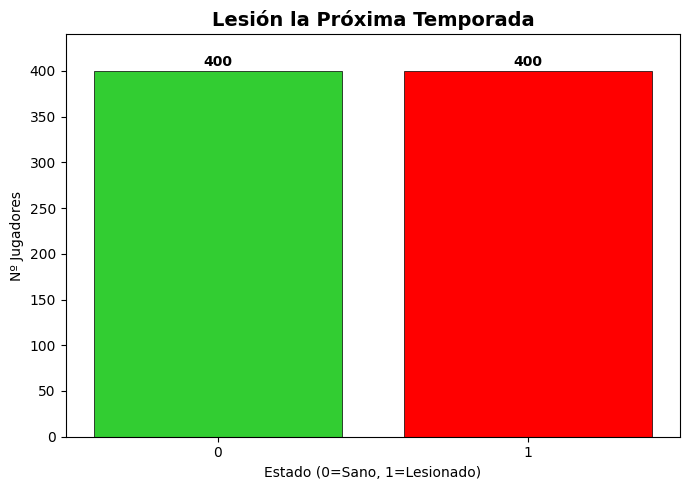

In [8]:
# Distribución del Target
print("\n--- DISTRIBUCIÓN DE Injury_Next_Season ---")

target= "Injury_Next_Season"
display(df[target].value_counts())

# 1. Datos
counttarget = df[target].value_counts().sort_index()

# 2. Configuración del Lienzo
fig, ax = plt.subplots(figsize=(7, 5))

# 3. Creación del Gráfico de Barras
ax.bar(counttarget.index.astype(str), counttarget.values, color=['limegreen', 'red'], edgecolor='black', linewidth=0.5 )

# 4. Personalización
ax.set_title("Lesión la Próxima Temporada", fontsize=14, fontweight='bold')
ax.set_xlabel("Estado (0=Sano, 1=Lesionado)")
ax.set_ylabel("Nº Jugadores")
ax.set_ylim(0, max(counttarget.values) * 1.1)

# 5. Añadir etiquetas de valor encima de las barras
for i, v in enumerate(counttarget.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Tenemos además otra variable binaria:  

* `Warmup_Routine_Adherence` → Binaria 0/1

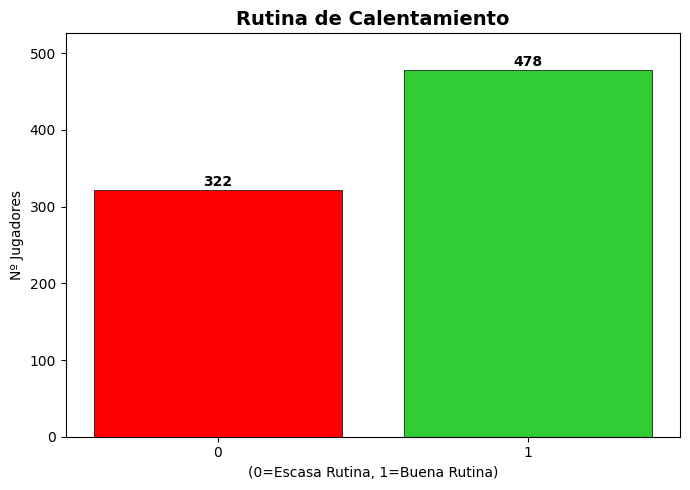

In [9]:
# 1. Datos
countwup = df["Warmup_Routine_Adherence"].value_counts().sort_index()

# 2. Configuración del Lienzo
fig, ax = plt.subplots(figsize=(7, 5))

# 3. Creación del Gráfico de Barras
ax.bar(countwup.index.astype(str), countwup.values, color=['red', 'limegreen'], edgecolor='black', linewidth=0.5)

# 4. Personalización
ax.set_title("Rutina de Calentamiento", fontsize=14, fontweight='bold')
ax.set_xlabel("(0=Escasa Rutina, 1=Buena Rutina)")
ax.set_ylabel("Nº Jugadores")
ax.set_ylim(0, max(countwup.values) * 1.1)

for i, v in enumerate(countwup.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
#### **2.2.2 Variables Numéricas Discretas**
Dentro de las variables numéricas tenemos 3 que son discretas (con pocos valores únicos):

* `Age` 

* `Matches_Played_Past_Season`

* `Previous_Injury_Count`

Para una mejor interpretación las visualizamos como variables categóricas (Gráficos de barras).

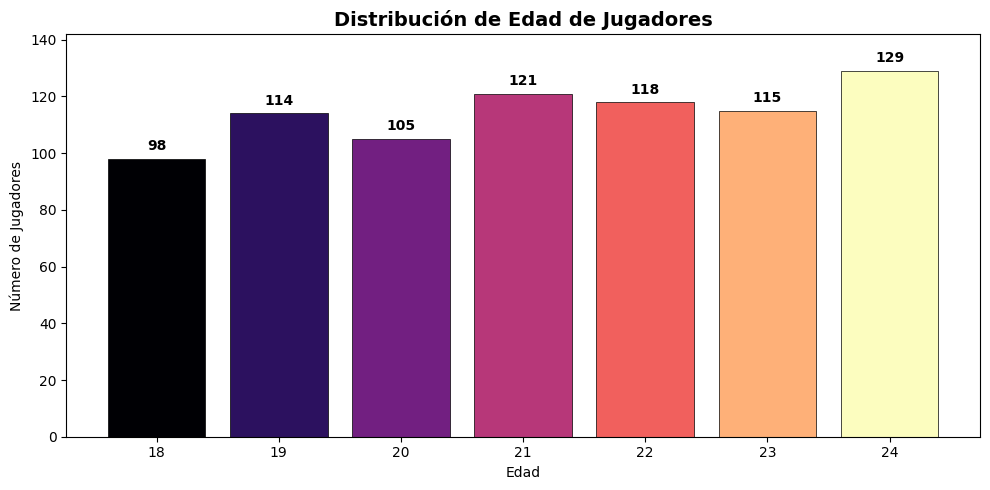

In [10]:
# Visualización de la distribución de Age
age = df['Age'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10,5))

colors3 = plt.get_cmap("magma")(np.linspace(0, 1, len(age)))
ax.bar(age.index.astype(str), age.values, color=colors3, edgecolor='black', linewidth=0.5 )
ax.set_title("Distribución de Edad de Jugadores", fontsize=14, fontweight='bold')  
ax.set_xlabel("Edad")
ax.set_ylabel("Número de Jugadores")
ax.set_ylim(0, max(age.values) * 1.1)

for i, v in enumerate(age.values):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

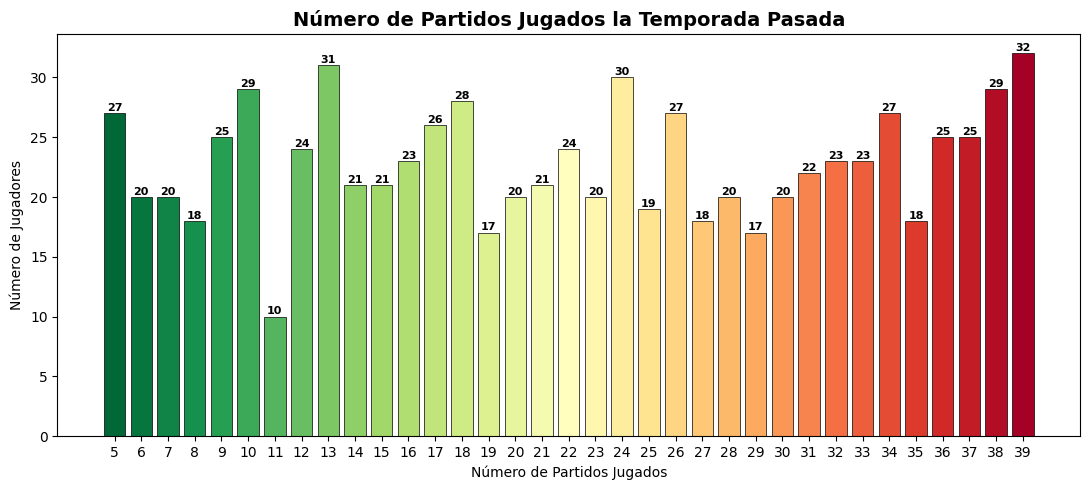

In [11]:
# Visualización de la distribución de matches_played_past_season
matches_played = df['Matches_Played_Past_Season'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11,5))

# Paleta de colores que va de verde a rojo con mayor número de partidos jugados
n_categorias = len(matches_played)
mapa_color = plt.get_cmap('RdYlGn_r')
colores8 = mapa_color(np.linspace(0, 1, n_categorias))

ax.bar(matches_played.index.astype(str), matches_played.values, color=colores8, edgecolor='black', linewidth=0.5 )

ax.set_title("Número de Partidos Jugados la Temporada Pasada", fontsize=14, fontweight='bold')  
ax.set_xlabel("Número de Partidos Jugados")
ax.set_ylabel("Número de Jugadores")

for i, v in enumerate(matches_played.values):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

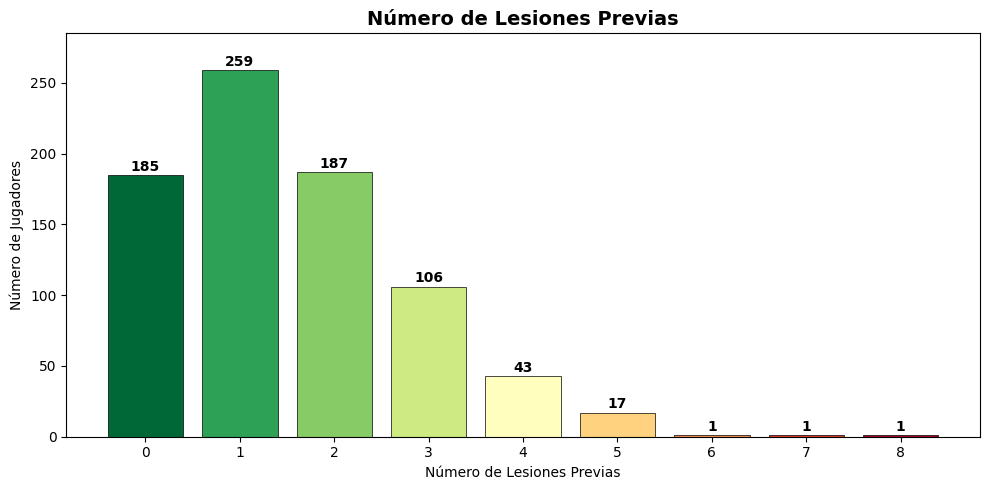

In [12]:
# Visualización de la distribución de previus_injury_counts
previus_injury_counts = df['Previous_Injury_Count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10,5))

# Paleta de colores que va de verde a rojo con mayor número de lesiones previas
n_categorias2 = len(previus_injury_counts)
mapa_color2 = plt.get_cmap('RdYlGn_r')
colores2 = mapa_color2(np.linspace(0, 1, n_categorias2))

ax.bar(previus_injury_counts.index.astype(str), previus_injury_counts.values, color=colores2, edgecolor='black', linewidth=0.5 )
ax.set_title("Número de Lesiones Previas", fontsize=14, fontweight='bold')  
ax.set_xlabel("Número de Lesiones Previas")
ax.set_ylabel("Número de Jugadores")
ax.set_ylim(0, max(previus_injury_counts.values) * 1.1)

for i, v in enumerate(previus_injury_counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
#### **2.2.3 Variables Numéricas Continuas**
Por último, ya solo nos quedan las **variables númericas continuas**.  

Realizamos un análisis univariante con **Histogramas** y comprobamos si existen outliers con **Boxplots**:

Este análisis es clave, nos permite evaluar la **calidad de los datos**, decidir si los outliers son errores, casos reales extremos o valores que requieren tratamiento antes del modelado.


In [13]:
# Listado de variables restantes
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "Injury_Next_Season" and c != "Previous_Injury_Count" and c != "Warmup_Routine_Adherence" and c != "Matches_Played_Past_Season" and c != "Age"]

print("--- Listado de Variables Numéricas Restantes ---\n")  
for col in numeric_cols:
    print(col)

--- Listado de Variables Numéricas Restantes ---

Height_cm
Weight_kg
Training_Hours_Per_Week
Knee_Strength_Score
Hamstring_Flexibility
Reaction_Time_ms
Balance_Test_Score
Sprint_Speed_10m_s
Agility_Score
Sleep_Hours_Per_Night
Stress_Level_Score
Nutrition_Quality_Score
BMI


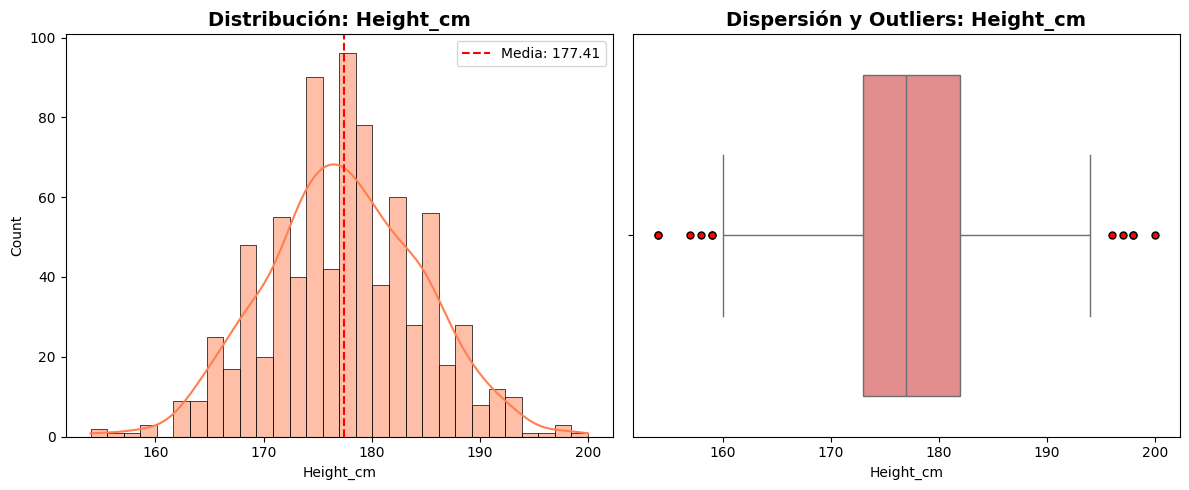

--- Análisis de Height_cm ---
count    800.00
mean     177.41
std        7.15
min      154.00
25%      173.00
50%      177.00
75%      182.00
max      200.00
Name: Height_cm, dtype: float64



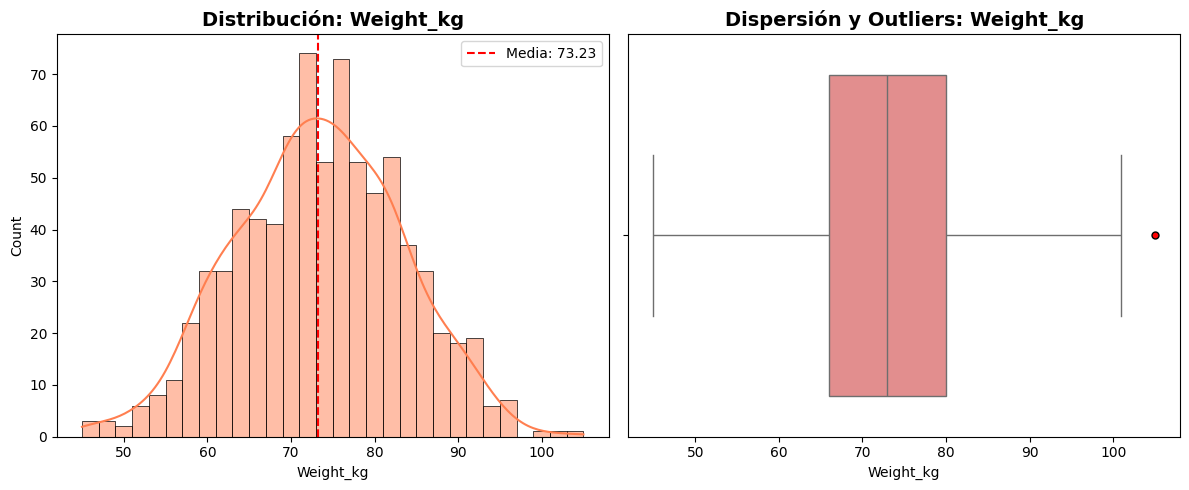

--- Análisis de Weight_kg ---
count    800.00
mean      73.24
std        9.93
min       45.00
25%       66.00
50%       73.00
75%       80.00
max      105.00
Name: Weight_kg, dtype: float64



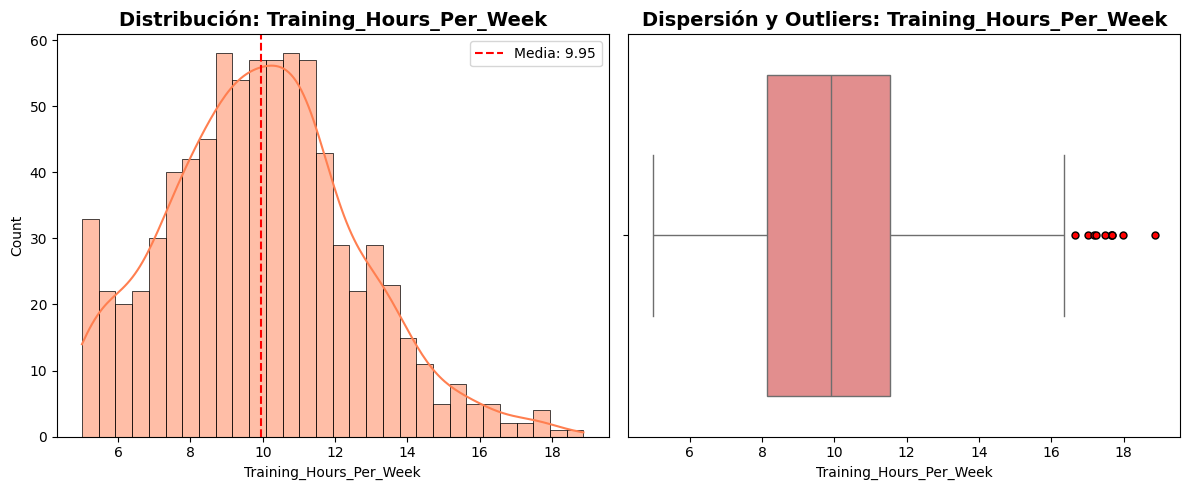

--- Análisis de Training_Hours_Per_Week ---
count    800.00
mean       9.95
std        2.61
min        5.00
25%        8.13
50%        9.90
75%       11.54
max       18.87
Name: Training_Hours_Per_Week, dtype: float64



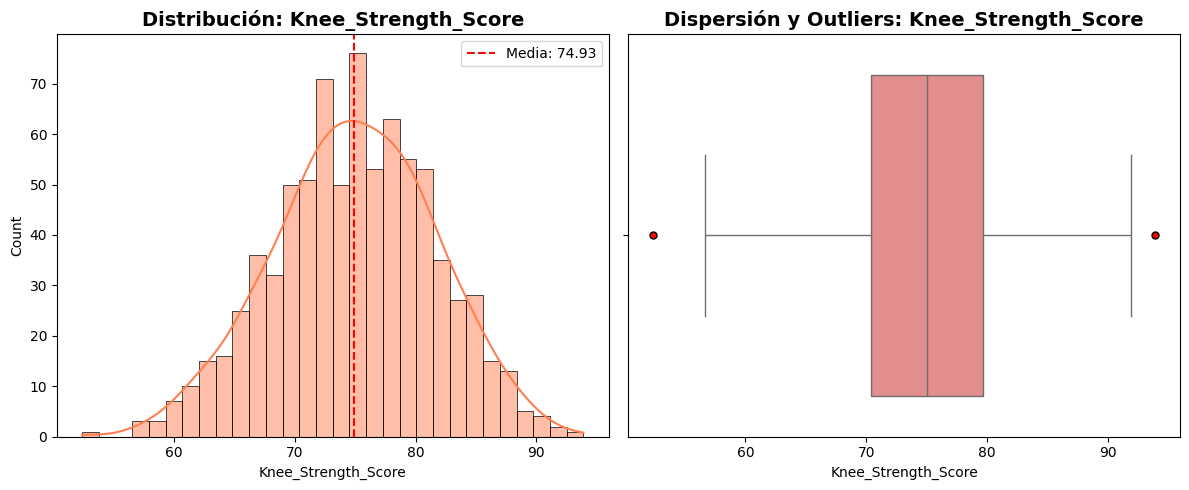

--- Análisis de Knee_Strength_Score ---
count    800.00
mean      74.93
std        6.67
min       52.39
25%       70.43
50%       75.00
75%       79.63
max       93.90
Name: Knee_Strength_Score, dtype: float64



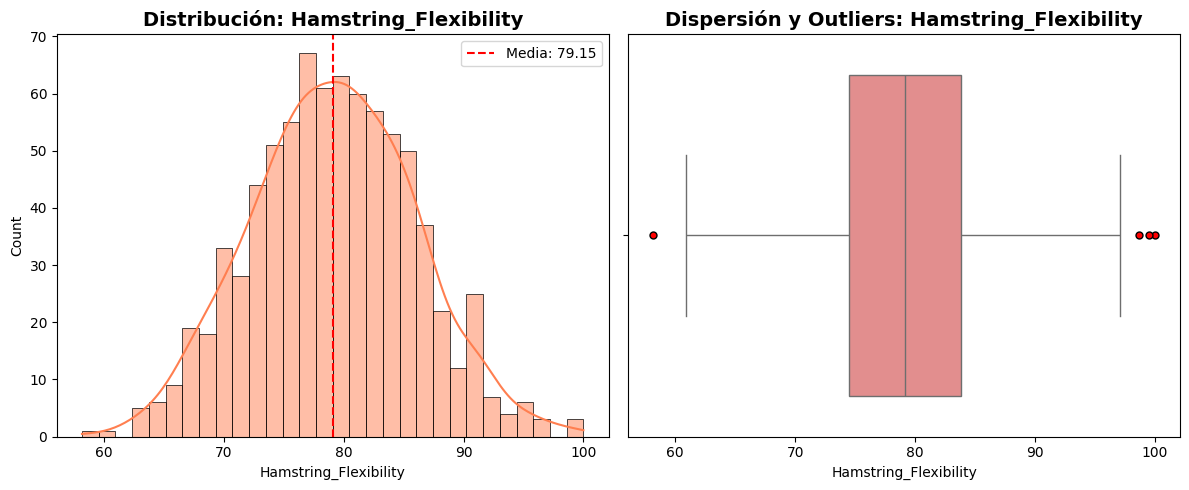

--- Análisis de Hamstring_Flexibility ---
count    800.00
mean      79.15
std        6.78
min       58.18
25%       74.50
50%       79.19
75%       83.81
max      100.00
Name: Hamstring_Flexibility, dtype: float64



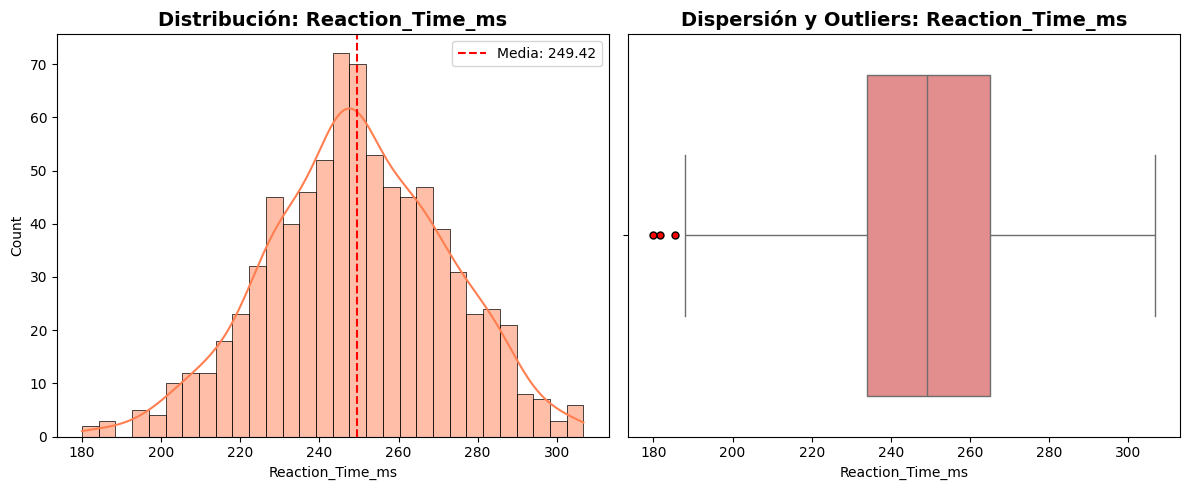

--- Análisis de Reaction_Time_ms ---
count    800.00
mean     249.42
std       22.53
min      180.00
25%      234.09
50%      249.13
75%      265.11
max      306.73
Name: Reaction_Time_ms, dtype: float64



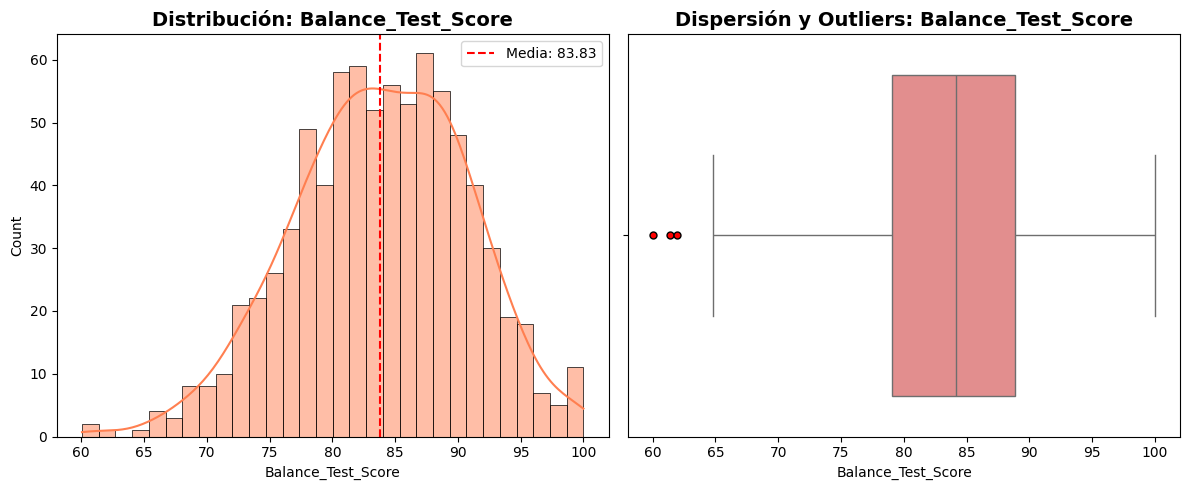

--- Análisis de Balance_Test_Score ---
count    800.00
mean      83.83
std        6.93
min       60.06
25%       79.04
50%       84.16
75%       88.88
max      100.00
Name: Balance_Test_Score, dtype: float64



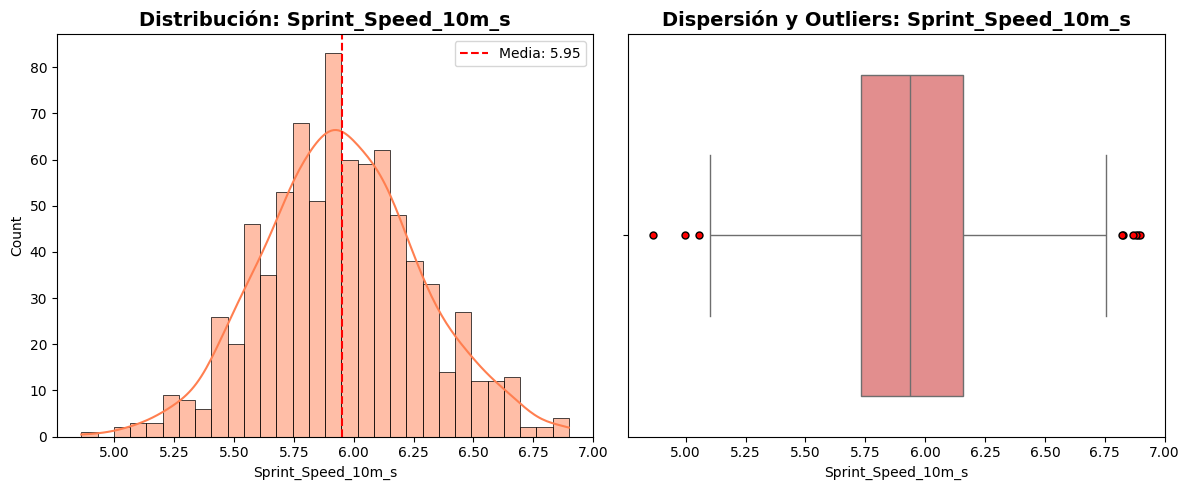

--- Análisis de Sprint_Speed_10m_s ---
count    800.00
mean       5.95
std        0.33
min        4.86
25%        5.73
50%        5.94
75%        6.16
max        6.90
Name: Sprint_Speed_10m_s, dtype: float64



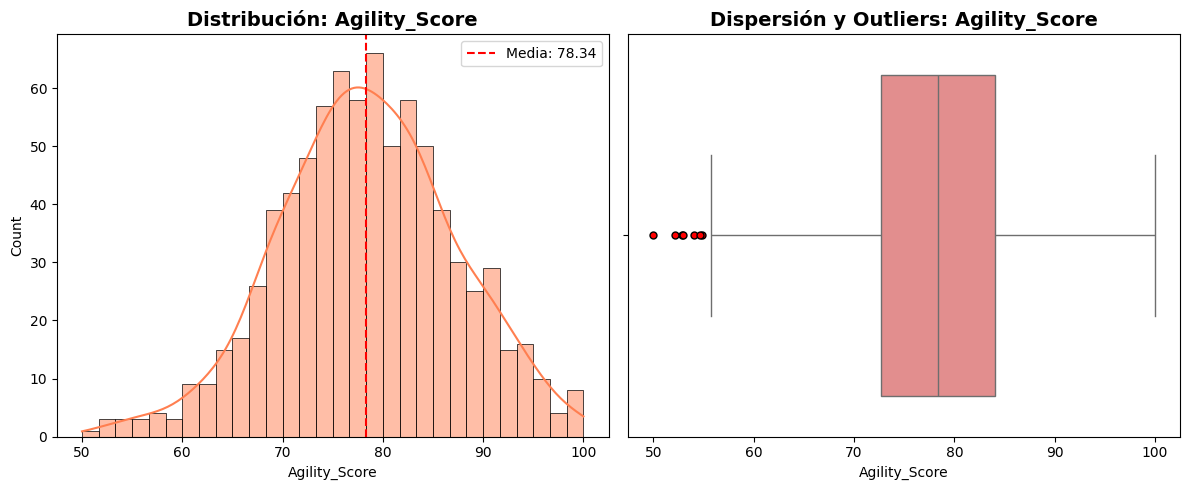

--- Análisis de Agility_Score ---
count    800.00
mean      78.34
std        8.78
min       50.00
25%       72.68
50%       78.34
75%       84.09
max      100.00
Name: Agility_Score, dtype: float64



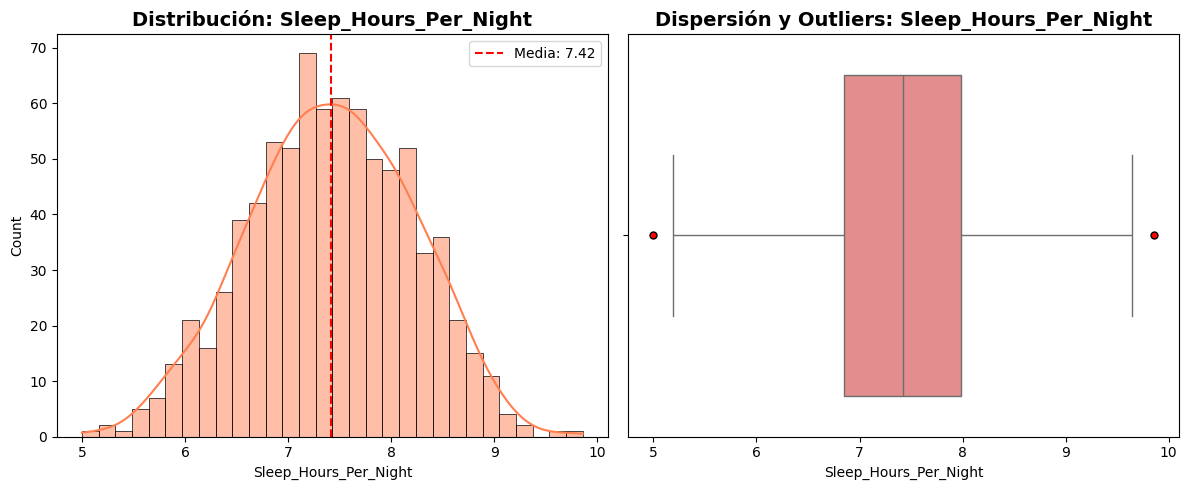

--- Análisis de Sleep_Hours_Per_Night ---
count    800.00
mean       7.42
std        0.79
min        5.00
25%        6.85
50%        7.42
75%        7.99
max        9.86
Name: Sleep_Hours_Per_Night, dtype: float64



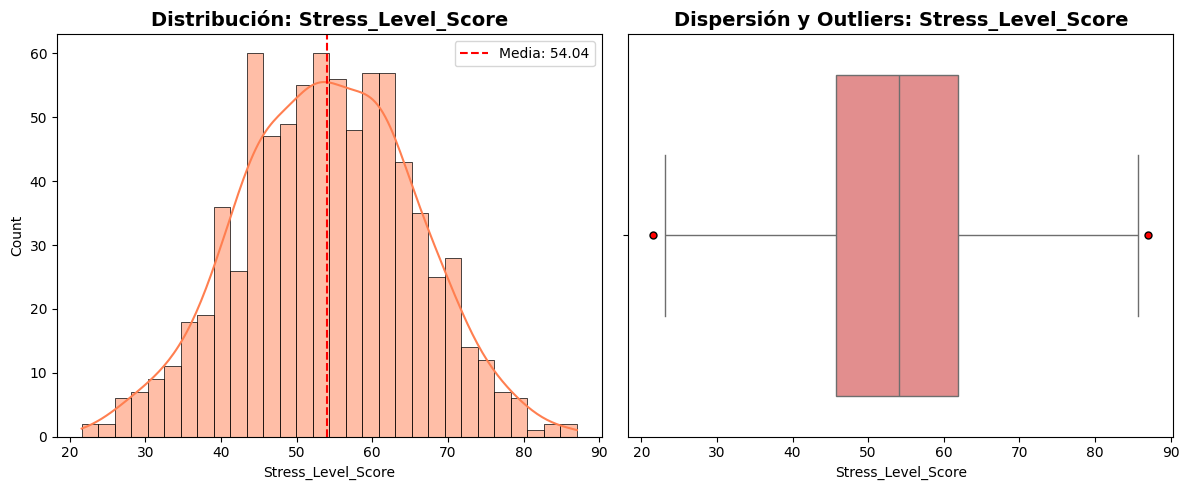

--- Análisis de Stress_Level_Score ---
count    800.00
mean      54.04
std       11.42
min       21.56
25%       45.78
50%       54.05
75%       61.91
max       87.07
Name: Stress_Level_Score, dtype: float64



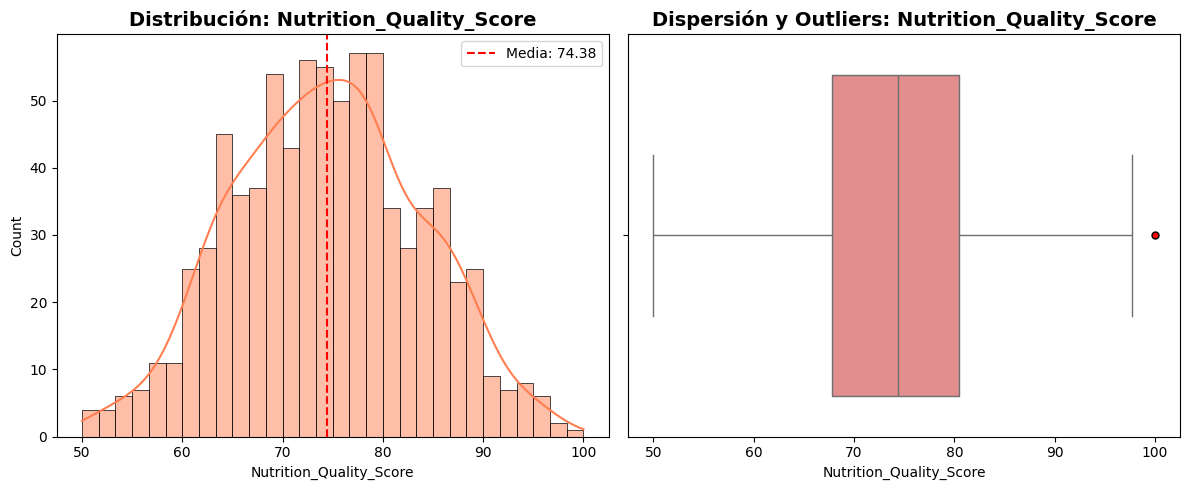

--- Análisis de Nutrition_Quality_Score ---
count    800.00
mean      74.38
std        9.32
min       50.00
25%       67.81
50%       74.36
75%       80.50
max      100.00
Name: Nutrition_Quality_Score, dtype: float64



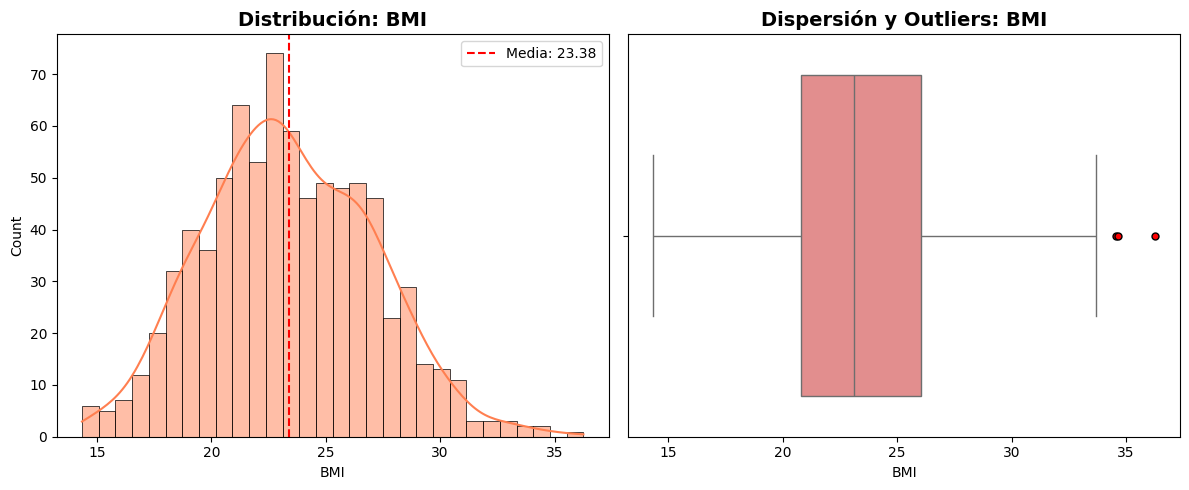

--- Análisis de BMI ---
count    800.00
mean      23.38
std        3.67
min       14.35
25%       20.79
50%       23.13
75%       26.02
max       36.26
Name: BMI, dtype: float64



In [14]:
# Representación de Variables Numéricas Restantes
for col in numeric_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # 1. Histograma con línea de media
    sns.histplot(x=col, data=df, kde=True, color="coral", ax=ax[0], bins=30, edgecolor='black', linewidth=0.5 )
    media = df[col].mean()
    ax[0].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    ax[0].set_title(f"Distribución: {col}", fontsize=14, fontweight='bold')
    ax[0].legend()

    # 2. Boxplot para detectar outliers
    sns.boxplot(x=col, data=df, color="lightcoral", ax=ax[1], fliersize=5, flierprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
    ax[1].set_title(f"Dispersión y Outliers: {col}", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 3. Análisis Estadístico
    print(f"--- Análisis de {col} ---")
    print(df[col].describe().round(2))

    print("\n" + "="*50)

### **2.3. Outliers**
Después de revisar los boxplots, aparecen algunos valores extremos, pero no son demasiados y no parecen repercuitr en la distribución general de las variables. Por eso, en este caso no aplicamos ningún tratamiento y los mantenemos en el dataset.

Si en cambio hubiéramos detectado outliers más frecuentes o muy alejados de la media, sí los habríamos gestionado con el método IQR para identificarlos y decidir aplicar un tratamiento sobre ellos.

De existir, con el siguiente código podriamos eliminarlos: 
```
# Definir una función para eliminar outliers basados en el IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Eliminar outliers en las columnas especificadas
for col in columns_with_outliers:
    df = remove_outliers(df, col)
```
---

### **2.4. Análisis Bivariante**

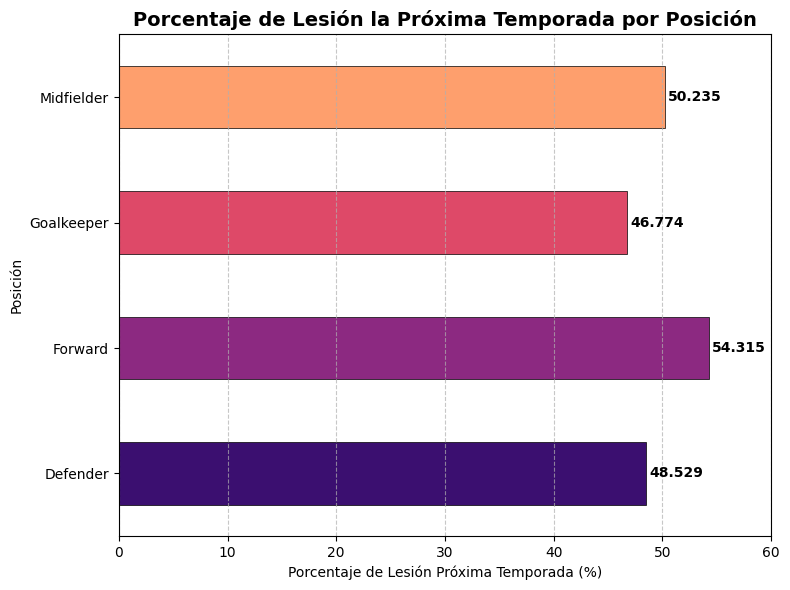


La posición con mayor probabilidad de lesión es Forward con un 54.31% de probabilidad.



In [15]:
# Análisis de la relación entre posición y probabilidad de lesión
inj_by_pos = (
    df.groupby("Position")["Injury_Next_Season"]
      .mean() * 100
      
)
colors = sns.color_palette('magma', n_colors=len(inj_by_pos))
fig, ax = plt.subplots(figsize=(8, 6))
ax = inj_by_pos.plot(kind="barh", title="Porcentaje de Lesión la Próxima Temporada por Posición", color=colors, edgecolor='black', linewidth=0.5)
ax.set_title("Porcentaje de Lesión la Próxima Temporada por Posición", fontsize=14, fontweight='bold')
ax.set_xlabel("Porcentaje de Lesión Próxima Temporada (%)")
ax.set_ylabel("Posición")


for i, v in enumerate(inj_by_pos):
    plt.text(v + 0.25, i, f'{v:.3f}', va='center', fontweight='bold')

# Modificación del rango del eje X
ax.set_xlim(left=0, right=60)

ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nLa posición con mayor probabilidad de lesión es {inj_by_pos.idxmax()} con un {inj_by_pos.max():.2f}% de probabilidad.\n")


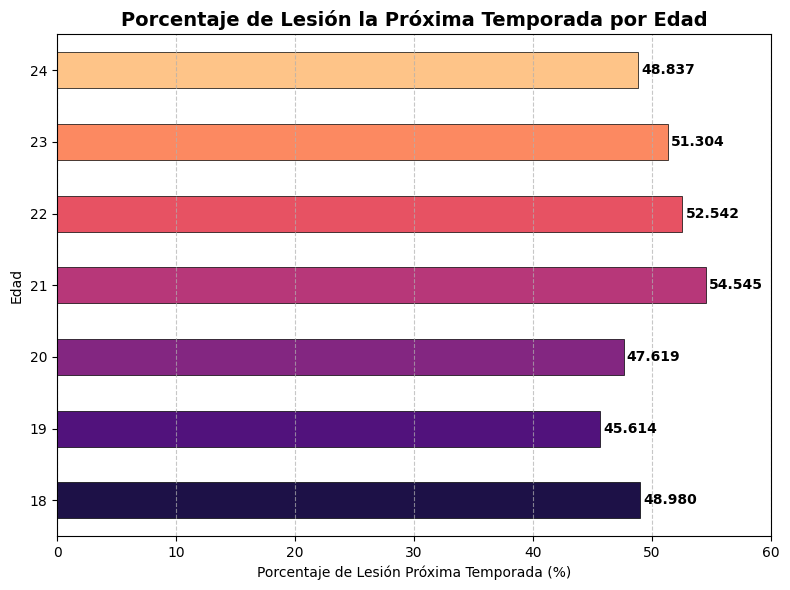

La edad con mayor probabilidad de lesión es 21 años con un 54.55% de probabilidad.



In [16]:
# Análisis de la relación entre edad y probabilidad de lesión
inj_by_age = (
    df.groupby("Age")["Injury_Next_Season"]
      .mean() * 100
)
colors = sns.color_palette('magma', n_colors=len(inj_by_age))
fig, ax = plt.subplots(figsize=(8, 6))
ax = inj_by_age.plot(kind="barh", title="Porcentaje de Lesión la Próxima Temporada por Edad", color=colors, edgecolor='black', linewidth=0.5)
ax.set_title("Porcentaje de Lesión la Próxima Temporada por Edad", fontsize=14, fontweight='bold')
ax.set_xlabel("Porcentaje de Lesión Próxima Temporada (%)")
ax.set_ylabel("Edad")


for i, v in enumerate(inj_by_age):
    plt.text(v + 0.25, i, f'{v:.3f}', va='center', fontweight='bold')

# Modificación del rango del eje X
ax.set_xlim(left=0, right=60)

ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"La edad con mayor probabilidad de lesión es {inj_by_age.idxmax()} años con un {inj_by_age.max():.2f}% de probabilidad.\n")

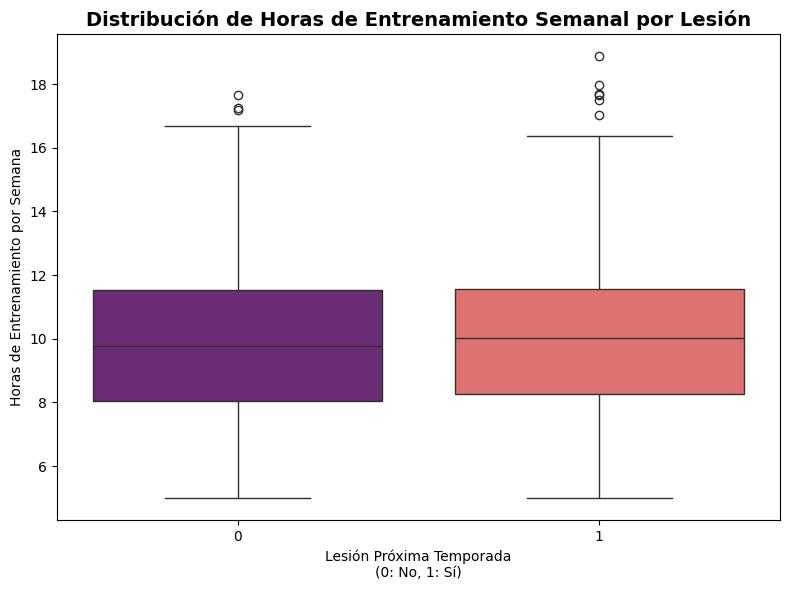


Se observa que los jugadores que se lesionan tienden a tener una mayor variabilidad en sus horas de entrenamiento semanal.



In [17]:
# Análisis de la relación entre horas de entrenamiento y probabilidad de lesión
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="Injury_Next_Season", y="Training_Hours_Per_Week", data=df, hue="Injury_Next_Season", palette='magma', 
            legend=False, ax=ax)

ax.set_title("Distribución de Horas de Entrenamiento Semanal por Lesión", fontsize=14, fontweight='bold')
ax.set_xlabel("Lesión Próxima Temporada\n(0: No, 1: Sí)")
ax.set_ylabel("Horas de Entrenamiento por Semana")


plt.tight_layout()
plt.show()

print("\nSe observa que los jugadores que se lesionan tienden a tener una mayor variabilidad en sus horas de entrenamiento semanal.\n")

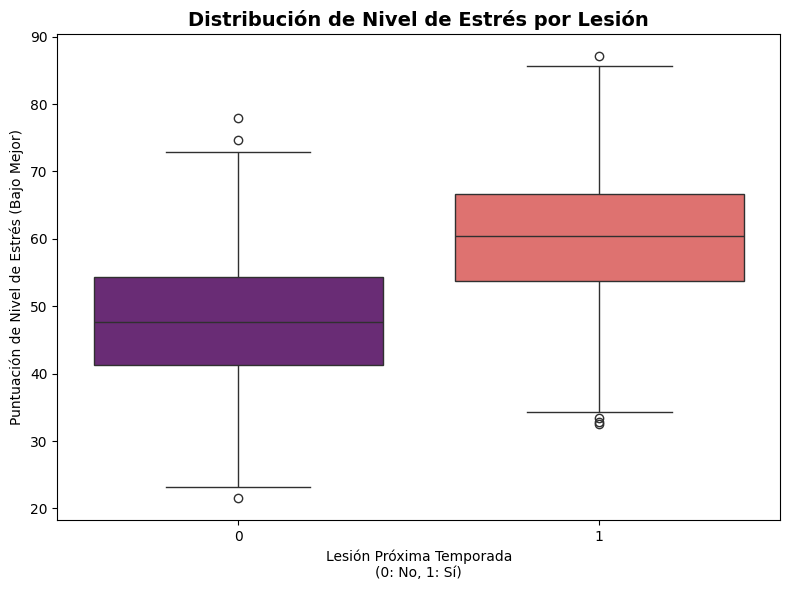


Se observa que los jugadores que se lesionan tienden a tener niveles de estrés más altos.



In [18]:
# Análisis de la relación entre nivel de estrés y probabilidad de lesión
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="Injury_Next_Season", y="Stress_Level_Score", data=df, hue="Injury_Next_Season", palette='magma', legend=False, ax=ax)

ax.set_title("Distribución de Nivel de Estrés por Lesión", fontsize=14, fontweight='bold')
ax.set_xlabel("Lesión Próxima Temporada\n(0: No, 1: Sí)")
ax.set_ylabel("Puntuación de Nivel de Estrés (Bajo Mejor)")


plt.tight_layout()
plt.show()

print("\nSe observa que los jugadores que se lesionan tienden a tener niveles de estrés más altos.\n")

---


### **2.5. Análisis de Correlación y Relación con la Lesión Futura**

Calculamos la **correlación entre las variables numéricas del dataset** para entender cómo se relacionan entre sí.

La correlación mide la relación lineal entre dos variables y varía entre -1 y 1. 
- Si es 1, significa una correlación positiva perfecta.
- Si es -1, indica una correlación negativa perfecta.
- Si es 0, no hay correlación lineal.

Primero generamos una **matriz de correlación** representada mediante un **mapa de calor**. Nos ofrece una visión de la relación lineal entre las variables.

Después, se analiza de forma específica la correlación de cada variable con `Injury_Next_Season`, ordenándolas de mayor a menor relación y visualizándolas en un **gráfico de barras**. Esto permite identificar qué métricas inlfuyen en mayor medida en la aparición de una lesión en la siguiente temporada.

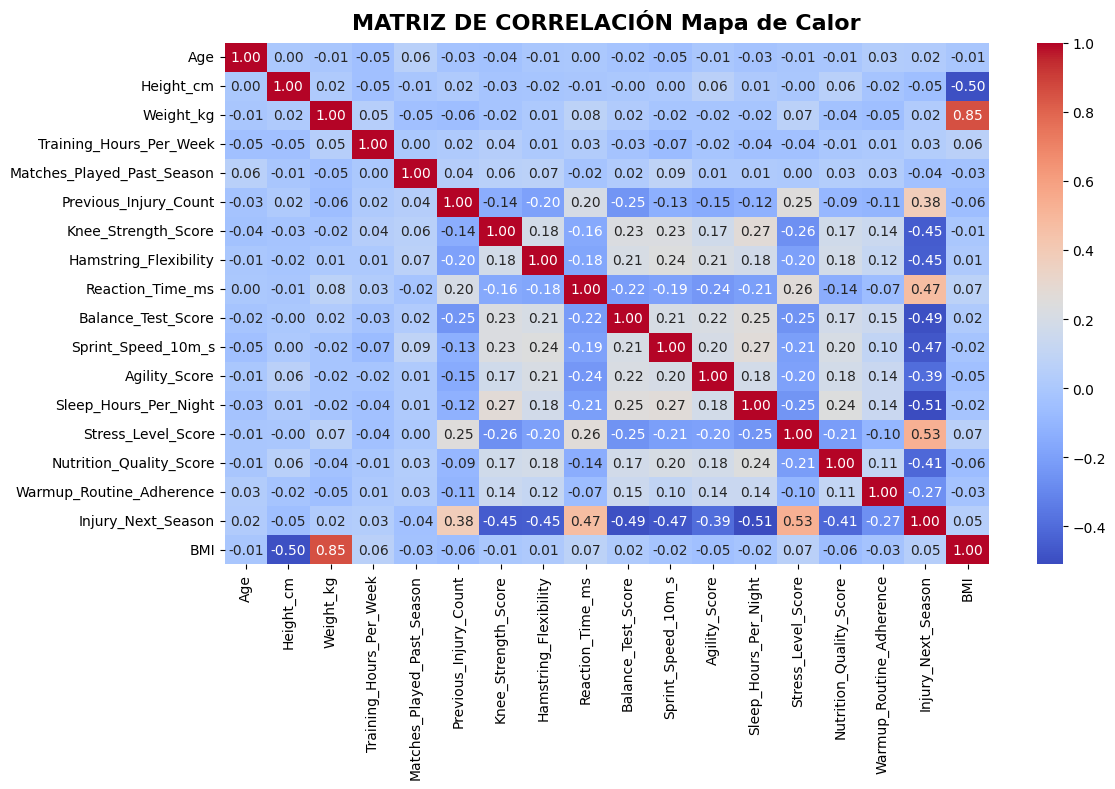

=== Relación de las Variables con Injury_Next_Season ===

Stress_Level_Score            0.529961
Reaction_Time_ms              0.470878
Previous_Injury_Count         0.382226
BMI                           0.047380
Training_Hours_Per_Week       0.033793
Age                           0.021359
Weight_kg                     0.021163
Matches_Played_Past_Season   -0.043910
Height_cm                    -0.054937
Warmup_Routine_Adherence     -0.265089
Agility_Score                -0.393681
Nutrition_Quality_Score      -0.412496
Hamstring_Flexibility        -0.450317
Knee_Strength_Score          -0.454551
Sprint_Speed_10m_s           -0.471499
Balance_Test_Score           -0.494814
Sleep_Hours_Per_Night        -0.510869
Name: Injury_Next_Season, dtype: float64


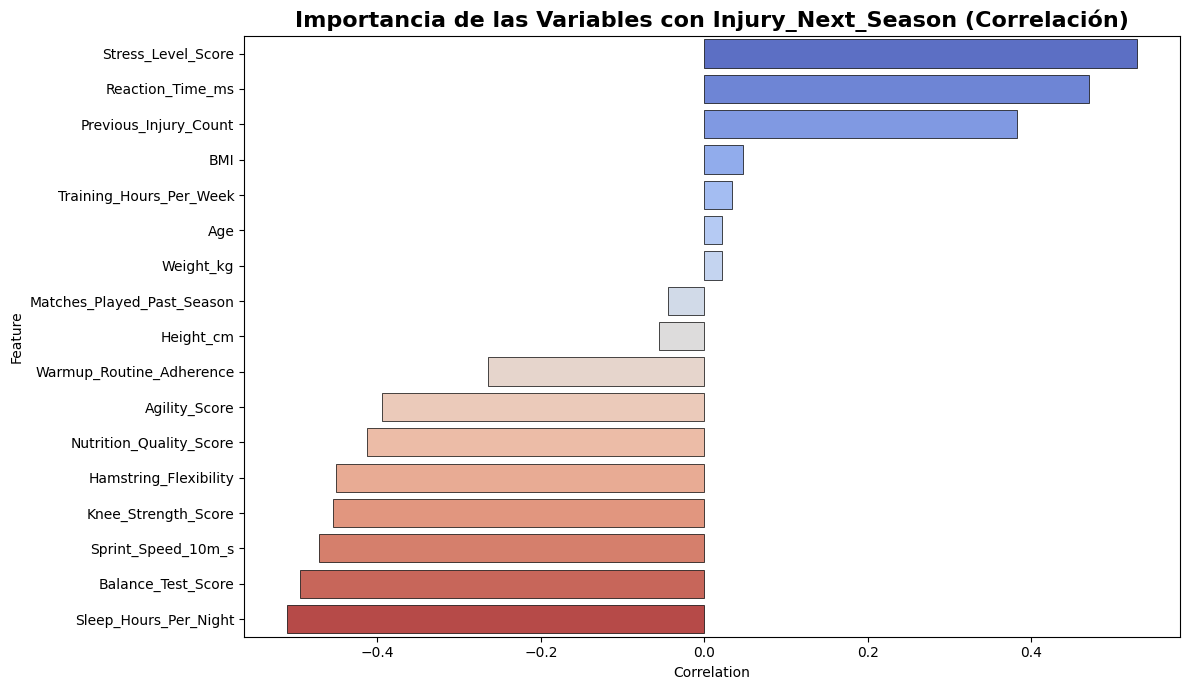

In [19]:
# Correlación de variables numéricas
cor = df.select_dtypes(include=np.number).corr()

plt.figure(figsize = (12,8))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('MATRIZ DE CORRELACIÓN Mapa de Calor', fontsize=16, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

# Correlación de las variables para Injury_Next_Season
imp = cor["Injury_Next_Season"].sort_values(ascending = False).drop("Injury_Next_Season")
print(f"=== Relación de las Variables con Injury_Next_Season ===\n\n{imp}")
imp_df = imp.reset_index()
imp_df.columns = ["Feature", "Correlation"]

# No mostrar el target en el gráfico
imp_df_no_target = imp_df[imp_df["Feature"] != "Injury_Next_Season"]

plt.figure(figsize=(12,7))
sns.barplot(x="Correlation", y="Feature", hue="Feature", data=imp_df_no_target, palette="coolwarm", legend=False, edgecolor='black', linewidth=0.5 )
plt.title("Importancia de las Variables con Injury_Next_Season (Correlación)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Relación entre las Variables y el Target:**

* **Principales contribuyentes positivos (factores de riesgo):**

  * Stress_Level_Score (+0.53)
  
  * Reaction_Time_ms (+0.47)
  
  * Previous_Injury_Count (+0.38)<br><br>




* **Principales contribuyentes negativos (factores protectores):**

  * Sleep_Hours_Per_Night (-0.51)
  
  * Balance_Test_Score (-0.49)
  
  * Sprint_Speed_10m_s (-0.47)
  
  * Knee_Strength_Score (-0.45)
  
  * Hamstring_Flexibility (-0.45)<br><br>


---


## **3. Preprocesamiento: Limpieza de Datos, Nulos y Feature Engineering**

Antes de aplicar cambios, creamos una copia del dataset `df_copy` y trabajamos sobre ella. Así mantenemos el df original intacto. Nos permite comparar el “antes y después” de cada paso y volver atrás si fuese necesario para si algo no cuadra.



In [20]:
df_copy = df.copy()

### **3.1 Limpieza y Gestión del Dataset**
  
- Comprobamos si existen **celdas vacías**.

In [21]:
# Nulos por Columna
print("\n--- VALORES NULOS POR COLUMNA ---")
df.isna().sum().sort_values(ascending=False)


--- VALORES NULOS POR COLUMNA ---


Age                           0
Balance_Test_Score            0
Injury_Next_Season            0
Warmup_Routine_Adherence      0
Nutrition_Quality_Score       0
Stress_Level_Score            0
Sleep_Hours_Per_Night         0
Agility_Score                 0
Sprint_Speed_10m_s            0
Reaction_Time_ms              0
Height_cm                     0
Hamstring_Flexibility         0
Knee_Strength_Score           0
Previous_Injury_Count         0
Matches_Played_Past_Season    0
Training_Hours_Per_Week       0
Position                      0
Weight_kg                     0
BMI                           0
dtype: int64

- Revisamos **valores duplicados**.

In [22]:
# Valores Duplicados
dup = df.duplicated().sum()
print("VALORES DUPLICADOS --->", dup, "\n")


VALORES DUPLICADOS ---> 0 



Podemos comprobar que no existen nulos ni duplicados, así que aquí no realizamos nada.

Cuando tenemos:

-**Duplicados**: se eliminan con `df.drop_duplicates()`.

-**Nulos**: Se tratan según sean variables:

* Numéricas: imputación con mediana (se rellena con el valor de la mediana de la variable). `df.fillna(df.mean(numeric_only=True), inplace=True)`


* Categóricas: imputación con moda (se rellena con la categoría más frecuente).

Alternativa: si hay muchos nulos en una fila/columna, se puede eliminar esa fila/columna si está justificado.


---

### **3.2. Tratamiento de Variables Categóricas**
La mayoría de los algoritmos de Machine Learning operan con datos numéricos. Por lo tanto, cualquier columna que contenga texto (variables categóricas) debe ser transformada a un formato numérico. 

Con `One-Hot Encoding` conviertimos cada categoría en una nueva columna binaria (con valores 0 o 1), evitando así introducir un orden artificial entre las categorías. En el caso de nuestro dataset:
- `Position` se transforma con **One-Hot Encoding** para convertir el texto (Categoría Nominal) en columnas binarias. 

**NOTA**: no utilizamos Label Encoding ya que `Position` se codificaría como números consecutivos (p. ej., 1=Defender, 2=Midfielder, 3=Forward), el modelo podría interpretar por error que existe un orden de importancia (“3 es más que 1”).

In [23]:
# Codificación One-Hot para la columna 'Position'
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
position_encoded = encoder.fit_transform(df_copy[['Position']])
position_df = pd.DataFrame(position_encoded, columns=encoder.get_feature_names_out(['Position']))

# Concatenar las nuevas columnas y eliminar la original
df_copy = pd.concat([df_copy.drop('Position', axis=1), position_df], axis=1)


display(df_copy[['Position_Defender', 'Position_Midfielder', 'Position_Forward', 'Position_Goalkeeper']].sample(5))



,Position_Defender,Position_Midfielder,Position_Forward,Position_Goalkeeper
138,0.0,0.0,0.0,1.0
456,0.0,0.0,0.0,1.0
621,0.0,0.0,0.0,1.0
15,0.0,1.0,0.0,0.0
740,1.0,0.0,0.0,0.0


**IMPORTANTE**: Random Forest no se afecta por transformaciones las variables y no requiere escalado o normalización de las features.

---

### **3.4. Feature Engineering**
Podemos crear dos variables derivadas, útiles para el contexto de este dataset:

  **1.** `Previous_Injury_Flag`: indica si el jugador tiene historial de lesión (1 si `Previous_Injury_Count > 0`).

In [24]:
# Crear la variable Previous_Injury_Flag
df_copy["Previous_Injury_Flag"] = (df_copy["Previous_Injury_Count"] > 0).astype(int)

  **2.** `Fitness_Composite`: Score compuesto de fitness (promedio de 4 métricas clave)

In [25]:
# Crear la variable Fitness_Composite
df_copy['Fitness_Composite'] = (df_copy['Knee_Strength_Score'] 
                                + df_copy['Hamstring_Flexibility'] 
                                + df_copy['Balance_Test_Score'] 
                                + df_copy['Agility_Score']) / 4

In [26]:
# Mostrar copia del dataset después del Preprocesamiento
print("=== Dataset después del Preprocesamiento ===\n")
print(f"Tamaño del dataset limpio: {df_copy.shape}")
df_copy.sample(5).round(3)


=== Dataset después del Preprocesamiento ===

Tamaño del dataset limpio: (800, 24)


,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,...,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI,Position_Defender,Position_Forward,Position_Goalkeeper,Position_Midfielder,Previous_Injury_Flag,Fitness_Composite
580,21,184,74,5.294,23,0,77.823,84.000,215.712,100.000,...,88.742,1,0,21.857,0.0,1.0,0.0,0.0,0,89.245
328,24,173,88,9.685,26,1,61.590,85.325,214.206,76.100,...,80.426,1,0,29.403,0.0,0.0,0.0,1.0,1,75.188
411,20,188,80,7.541,5,1,81.284,77.060,231.358,79.334,...,72.974,1,0,22.635,1.0,0.0,0.0,0.0,1,78.588
316,20,181,70,13.244,5,1,73.038,77.348,246.680,87.627,...,67.602,0,0,21.367,1.0,0.0,0.0,0.0,1,78.197
738,23,178,68,12.712,13,1,77.217,75.080,264.865,67.066,...,63.747,0,1,21.462,0.0,0.0,0.0,1.0,1,72.450


---

## **4. Definición del Target: Selección y Justificación**

**Target Seleccionado:** `Injury_Next_Season` Esta variable representa si el jugador sufrió una lesión que causó ≥7 días de ausencia en la siguiente temporada.

Justificación:
- Es una variable binaria (0/1), por tanto planteamos un problema de **clasificación**.
  
- El objetivo es relevante en el contexto deportivo, podemos predecir el riesgo de lesión de un jugador y optar por estrategias de prevención.
  
- El dataset contiene la variable target, lo que permite aplicar modelos de aprendizaje supervisado.

In [27]:
from pathlib import Path

# Cambiar esta ruta por la carpeta de destino deseada
target_dir = Path("/Users/mariogodoy/PYTHONIA/Master-IA-Universidad-Europea-25-26/dataset")
target_dir.mkdir(parents=True, exist_ok=True)

# Guardar CSVs en la carpeta destino
df.to_csv(target_dir / 'dataset_originalfotballmod2.csv', index=False)
print(f"Descargado dataset original en: {target_dir / 'dataset_originalfotballmod2.csv'}")

df_copy.to_csv(target_dir / 'dataset_limpio_final_fotball_mod2.csv', index=False)
print(f"Descargado dataset limpio en: {target_dir / 'dataset_limpio_final_fotball_mod2.csv'}")

Descargado dataset original en: /Users/mariogodoy/PYTHONIA/Master-IA-Universidad-Europea-25-26/dataset/dataset_originalfotballmod2.csv
Descargado dataset limpio en: /Users/mariogodoy/PYTHONIA/Master-IA-Universidad-Europea-25-26/dataset/dataset_limpio_final_fotball_mod2.csv


In [28]:
# Separar variables (X) y target (y)
X = df_copy.drop(target, axis=1)  # Todas las columnas excepto el target
y = df_copy[target]               # Solo el target

X.shape, y.shape

print(f"X tiene {X.shape[0]} filas (jugadores) y {X.shape[1]} columnas (variables predictoras).\n")
print(f"y tiene {y.shape[0]} valores (una etiqueta Injury_Next_Season por jugador).")

X tiene 800 filas (jugadores) y 23 columnas (variables predictoras).

y tiene 800 valores (una etiqueta Injury_Next_Season por jugador).


---

## **5. Algoritmo: Elección y Justificación**

**Algoritmo elegido:** Random Forest Classifier (Bosque de Árboles Aleatorio).

**Justificación:**
Un bosque de árboles es un conjunto de árboles de decisión que trabajan juntos para tomar una decisión final. La predicción final no depende de un solo árbol, sino de la combinación de los resultados de todos ellos. En problemas de clasificación normalmente se lleva a cabo por "votación".

Un árbol de decisión divide los datos basándose en condiciones sucesivas (nodos) hasta llegar a una hoja (resultado final). Es fácil de interpretar, pero tiende al sobreajuste; aprende muy bien los datos de entrenamiento pero generaliza peor cuando se enfrenta a datos nuevos.

Para evitar ese problema, en los bosques, no todos los árboles ven los mismos datos; cada uno se entrena utilizando un subconjunto aleatorio de los datos totales de entrenamiento, lo que aporta variedad entre modelos y reduce la dependencia de un único patrón.

**Bagging** y **Random Forest** son modelos de Bosques de Árboles, ambos utilizan un entrenamiento en paralelo. 

-Bagging crea múltiples copias de los datos originales con diferentes filas selecionadas aleatoriamente, entrena un árbol con cada copia y combina sus predicciones. 

-Random Forest es una evolución del bagging, ya que añade una capa extra de aleatoriedad: además de entrenar cada árbol con filas distintas, cada árbol solo ve un subconjunto de columnas (características) en cada división. Esta doble aleatoriedad reduce el sobreajuste y “descorrelaciona” los árboles.

Además este último modelo:
- Captura relaciones no lineales e interacciones complejas entre las variables (una lesión no es un fenomeno donde los factores de riesgo actúan de manera lineal).
- Maneja bien datasets con variables numéricas y categóricas.
- No requiere escalado o normalización de las features.
- Permite extraer la importancia que da el modelo a cada variable, siendo muy útil para interpretar los principales factores de riesgo de las lesiones.

--> Por ello **Random Forest** a priori es el modelo más adecuado para este contexto. No obstante, eso se podrá comprobar evaluando el `accuracy` al implementar y comparar diferentes modelos. (En este dataset, solo aplicaremos Random Forest)

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Elegir el algoritmo: RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,  # Número de árboles en el bosque
                               random_state=42)   # Semilla para reproducibilidad

# Mostrar configuración del modelo
print(f"Modelo seleccionado: {model} con {model.n_estimators} árboles de decisión.")

Modelo seleccionado: RandomForestClassifier(random_state=42) con 100 árboles de decisión.


---

# **6. Entrenamiento**
Vamos a entrenar el modelo. Usaremos el algoritmo previamente creado, RANDOM FOREST CLASSIFIER:

**1.**  **`Split`:** Separamos los datos. 80% para estudiar (Train) y 20% para el examen (Test).
   
**2.**  **`Fit`:** El modelo estudia los patrones.

In [30]:
# Importar librerías
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Dividir el dataset en train (80%) y test (20%): test_size=0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


**3.**  **`Predict`:** El modelo hace el examen con datos que no ha visto.
   
**4.**  **`Accuracy`:** El porcentaje total de aciertos.

In [31]:
# 3. Predecir en el conjunto de test
y_pred = model.predict(X_test)

# 4. Evaluar precisión general (accuracy)
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "═" * 37)
print(f"Precisión General en Test ===> {accuracy * 100:.2f}%")
print("═" * 37)



═════════════════════════════════════
Precisión General en Test ===> 92.50%
═════════════════════════════════════


**5.**  **`Feature_importances_`**: Mostrar importancia de las variables para el modelo.
   
**6.**  **`Sns.barplot`:** gráfico para la visualización de las 10 variables más importantes.

=== Importancia de Variables: ===

Fitness_Composite             0.230919
Sleep_Hours_Per_Night         0.101102
Stress_Level_Score            0.100852
Balance_Test_Score            0.090127
Reaction_Time_ms              0.084182
Sprint_Speed_10m_s            0.071500
Knee_Strength_Score           0.056417
Nutrition_Quality_Score       0.055773
Hamstring_Flexibility         0.045959
Agility_Score                 0.031787
Previous_Injury_Count         0.027756
Training_Hours_Per_Week       0.017417
Height_cm                     0.015263
BMI                           0.013501
Matches_Played_Past_Season    0.013211
Weight_kg                     0.013013
Previous_Injury_Flag          0.009981
Age                           0.006868
Warmup_Routine_Adherence      0.005475
Position_Forward              0.003110
Position_Defender             0.002478
Position_Goalkeeper           0.002056
Position_Midfielder           0.001252
dtype: float64


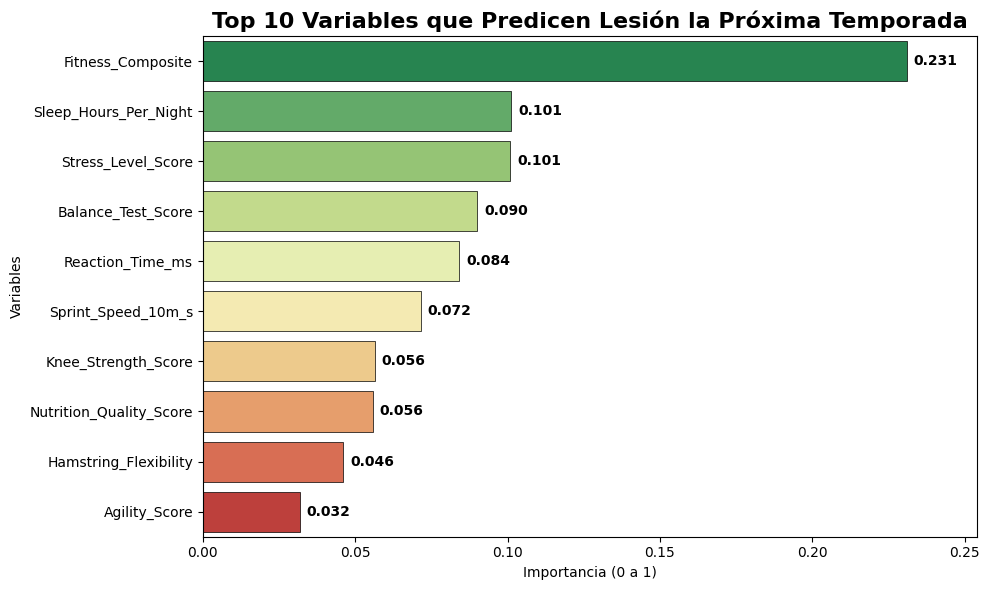

In [32]:
# 5. Mostrar importancia de variables (features)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("=== Importancia de Variables: ===\n")
print(importances)

# 6. Gráfico de Importancia de Variables. Visualización de las 10 variables más importantes
top_n = 10
top_importances = importances.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(
    x=top_importances.values,
    y=top_importances.index,
    hue=top_importances.index,
    palette="RdYlGn_r", 
    legend=False,
    edgecolor="black", linewidth=0.5
)
ax.set_title("Top 10 Variables que Predicen Lesión la Próxima Temporada", fontsize=16, fontweight='bold')
ax.set_xlabel("Importancia (0 a 1)")
ax.set_ylabel("Variables")
ax.set_xlim(0, top_importances.max() * 1.1)

# Etiquetas de valor en cada barra
for i, v in enumerate(top_importances.values):
    ax.text(v + (top_importances.max() * 0.01), i, f"{v:.3f}", va="center", fontweight='bold')

plt.tight_layout()
plt.show()

## **7. Crear un Nuevo Jugador Ficticio**
A partir de valores selecionados de un nuevo jugador, podemos ver la predicción de lesión.

In [33]:
# Probar el modelo con valores de un jugador ficticio nuevo
# PRUEBA A AJUSTAR LOS VALORES CON ****, PARA VER CÓMO CAMBIA LA PREDICCIÓN

new_data = {
    # Variables más importantes
    "Nombre_Jugador": ["Jugador_Ficticio_01"],
    'Fitness_Composite': [(80 + 85 + 90 + 85) / 4],                 # ****   
    'Sleep_Hours_Per_Night': [8],                                   # ****   
    'Stress_Level_Score': [50],                                     # ****   
    'Balance_Test_Score': [90],                                     # **** 
    'Reaction_Time_ms': [250],                                      # ****   
    'Sprint_Speed_10m_s': [6.0],                                    # **** 
    'Knee_Strength_Score': [80],                                    # ****   
    'Nutrition_Quality_Score': [80],                                # ****   
    'Hamstring_Flexibility': [85],                                  # ****   
    'Agility_Score': [85],                                          # ****   
    
    # Resto de variables
    'Age': [20],
    'Height_cm': [175],
    'Weight_kg': [70],
    'BMI': [22.86],
    'Training_Hours_Per_Week': [10],
    'Matches_Played_Past_Season': [20],
    'Previous_Injury_Count': [1],
    'Warmup_Routine_Adherence': [1],
    
    # Variables de posición (one-hot)
    'Position_Defender': [0],
    'Position_Forward': [0],
    'Position_Goalkeeper': [0],
    'Position_Midfielder': [1],
 
    'Previous_Injury_Flag': [1]
}


new_player = pd.DataFrame(new_data)
new_player = new_player[X.columns]  # Asegurar mismo orden de columnas que X

# Predecir para el nuevo jugador
pred = model.predict(new_player)[0]
nombre_jugador = new_data["Nombre_Jugador"][0]
print("\n" + "═" * 80)
print("                  RESULTADO DE LA PREDICCIÓN DEL MODELO                  ")
print("═" * 80)
print(f"                             {pred} ==> {'NO LESIÓN' if pred == 0 else 'POSIBLE LESIÓN'}")
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
                  RESULTADO DE LA PREDICCIÓN DEL MODELO                  
════════════════════════════════════════════════════════════════════════════════
                             0 ==> NO LESIÓN
════════════════════════════════════════════════════════════════════════════════
